In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV,StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve, roc_auc_score
from collections import Counter
%matplotlib inline

In [2]:
## Create the dataset
X,y = make_classification(n_samples = 1000, n_features = 10, n_classes = 2, random_state = 42)

In [3]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25, random_state = 42)

In [4]:
dummy_model_prob = [0 for _ in range(len(y_test))]  # Predicting all zeros as probabilities

In [5]:
model = LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
model_prob = model.predict_proba(X_test)[:,1]

In [10]:
dummy_model_auc = roc_auc_score(y_test, dummy_model_prob)
model_auc = roc_auc_score(y_test, model_prob)
print(f"Dummy Model AUC: {dummy_model_auc}")
print(f"Logistic Regression Model AUC: {model_auc}")

Dummy Model AUC: 0.5
Logistic Regression Model AUC: 0.922033460370777


In [12]:
dummy_fpr, dummy_tpr, dummy_thresholds = roc_curve(y_test, dummy_model_prob)
model_fpr, model_tpr, model_thresholds = roc_curve(y_test, model_prob)

In [13]:
model_fpr

array([0.        , 0.        , 0.        , 0.00884956, 0.00884956,
       0.03539823, 0.03539823, 0.04424779, 0.04424779, 0.07079646,
       0.07079646, 0.07964602, 0.07964602, 0.08849558, 0.08849558,
       0.11504425, 0.11504425, 0.12389381, 0.12389381, 0.14159292,
       0.14159292, 0.15044248, 0.15044248, 0.15929204, 0.15929204,
       0.16814159, 0.16814159, 0.17699115, 0.17699115, 0.22123894,
       0.22123894, 0.25663717, 0.25663717, 0.2920354 , 0.2920354 ,
       0.44247788, 0.44247788, 0.49557522, 0.49557522, 0.57522124,
       0.57522124, 0.6460177 , 0.6460177 , 0.69026549, 0.69026549,
       0.74336283, 0.74336283, 0.81415929, 0.81415929, 1.        ])

In [14]:
model_tpr

array([0.        , 0.00729927, 0.49635036, 0.49635036, 0.51094891,
       0.51094891, 0.62773723, 0.62773723, 0.72262774, 0.72262774,
       0.75182482, 0.75182482, 0.76642336, 0.76642336, 0.80291971,
       0.80291971, 0.81021898, 0.81021898, 0.81751825, 0.81751825,
       0.83211679, 0.83211679, 0.8540146 , 0.8540146 , 0.86861314,
       0.86861314, 0.87591241, 0.87591241, 0.89051095, 0.89051095,
       0.91240876, 0.91240876, 0.93430657, 0.93430657, 0.94160584,
       0.94160584, 0.94890511, 0.94890511, 0.95620438, 0.95620438,
       0.96350365, 0.96350365, 0.97080292, 0.97080292, 0.98540146,
       0.98540146, 0.99270073, 0.99270073, 1.        , 1.        ])

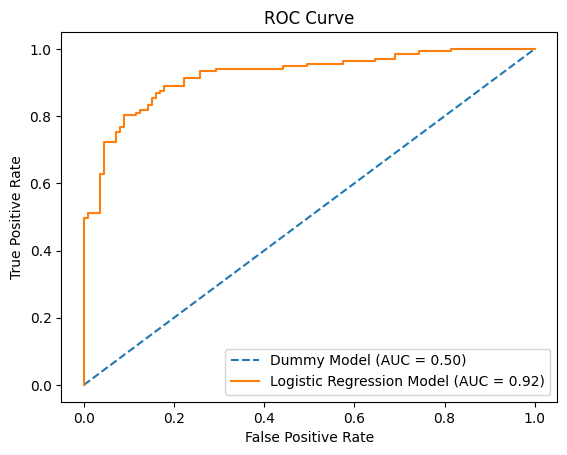

In [15]:
plt.plot(dummy_fpr, dummy_tpr, linestyle = '--', label = 'Dummy Model (AUC = {:.2f})'.format(dummy_model_auc))
plt.plot(model_fpr, model_tpr, linestyle = '-', label = 'Logistic Regression Model (AUC = {:.2f})'.format(model_auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

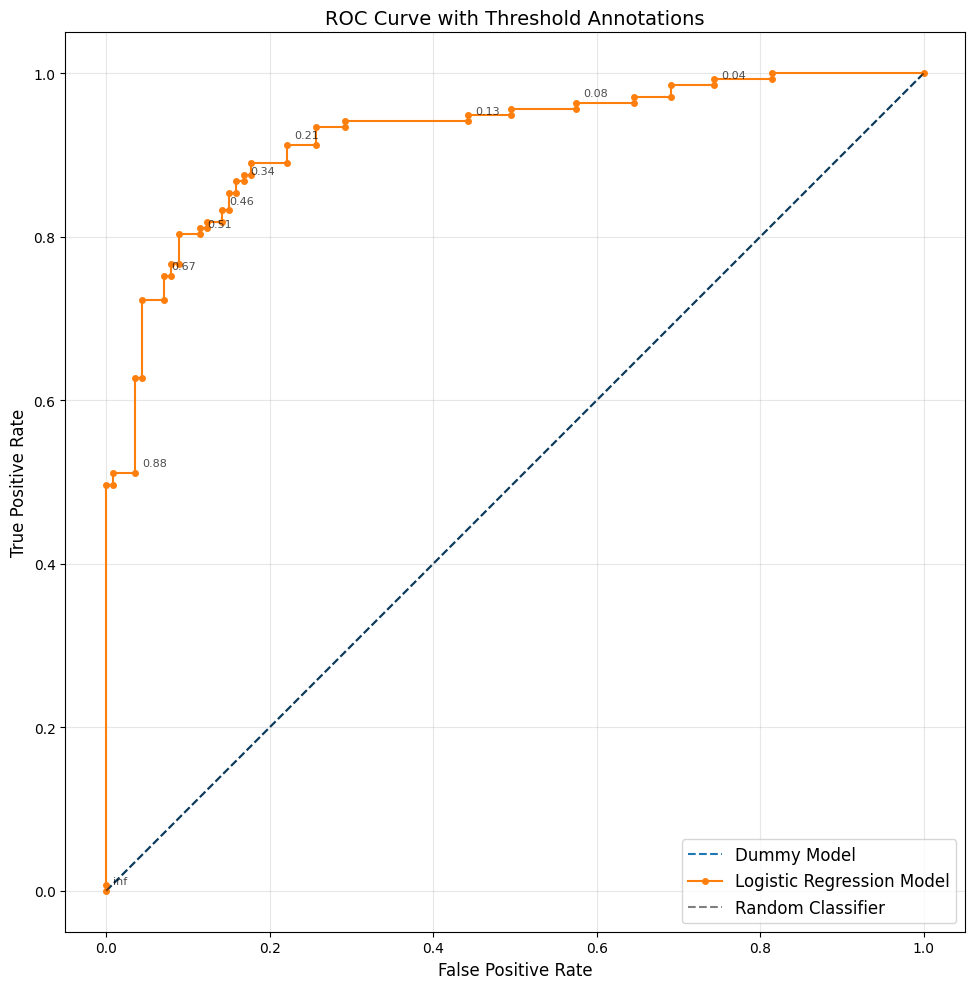

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure and axes FIRST
fig, ax = plt.subplots(figsize=(20, 10))

# Plot the ROC curves on the axes
ax.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
ax.plot(model_fpr, model_tpr, marker='.', label='Logistic Regression Model', markersize=8)

# Add annotations for thresholds (optional - careful with too many points)
# You might want to annotate only some points to avoid clutter
for i, (fpr, tpr, thresh) in enumerate(zip(model_fpr, model_tpr, model_thresholds)):
    if i % 5 == 0:  # Annotate every 5th point to reduce clutter
        ax.annotate(f'{thresh:.2f}', xy=(fpr, tpr), xytext=(5, 5), 
                   textcoords='offset points', fontsize=8, alpha=0.7)

# Add diagonal reference line
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')

# Set labels and title
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve with Threshold Annotations', fontsize=14)

# Add legend
ax.legend(fontsize=12)

# Add grid for better readability
ax.grid(True, alpha=0.3)

# Set aspect ratio to be equal
ax.set_aspect('equal')

plt.tight_layout()
plt.show()